# Exploration approfondie de la base d'apprentissage

In [197]:
import pandas as pd
import sys
import os
import warnings

warnings.filterwarnings("ignore")

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions"))

%load_ext autoreload
%autoreload 

from eda import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [198]:
# Configuration
FILE_PATH = "../data_finale/base_apprentissage_maj.csv"
TARGET    = "market_value_in_eur"
dossier_sauvegarde = "../outputs/eda"

In [199]:
# Chargement de la base de données

df_base = pd.read_csv(FILE_PATH)

In [200]:
print("Types des variables")

analyser_types(df_base)

Types des variables
Analyse des types de variables
Variables numériques   : 231
Variables catégorielles: 4


Analyse des valeurs manquantes
                        nb_missing    pct
contrat_jours_restants        3897  25.20
market_value_in_eur           2637  17.05
nation                           4   0.03

Graphique sauvegardé sous : ..\outputs\eda\valeurs_manquantes.png


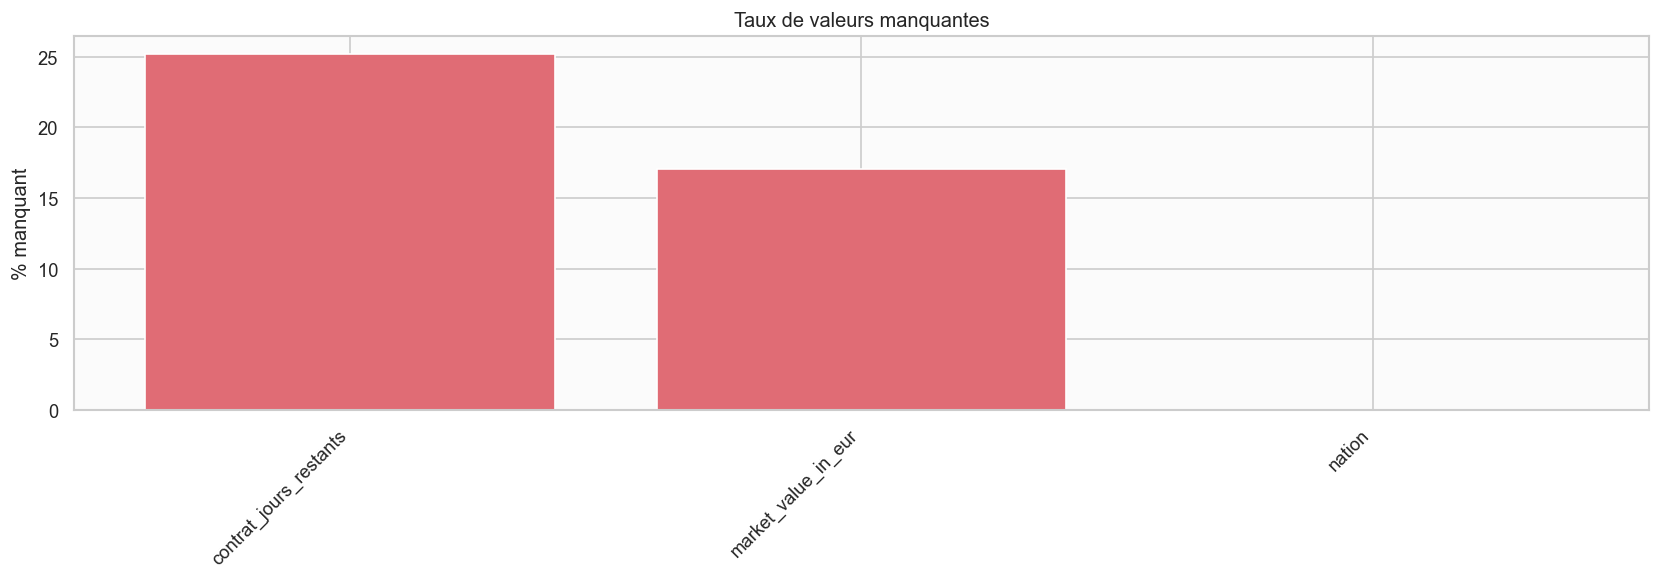

In [201]:
analyser_valeurs_manquantes(df_base, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la variable cible : market_value_in_eur
count         12,829
mean      12,027,050
std       17,094,496
min           50,000
25%        2,000,000
50%        5,000,000
75%       15,000,000
max      200,000,000
Name: market_value_in_eur, dtype: str

Skewness : 3.37
Kurtosis : 17.31

Graphique sauvegardé sous : ..\outputs\eda\distribution_market_value_in_eur.png


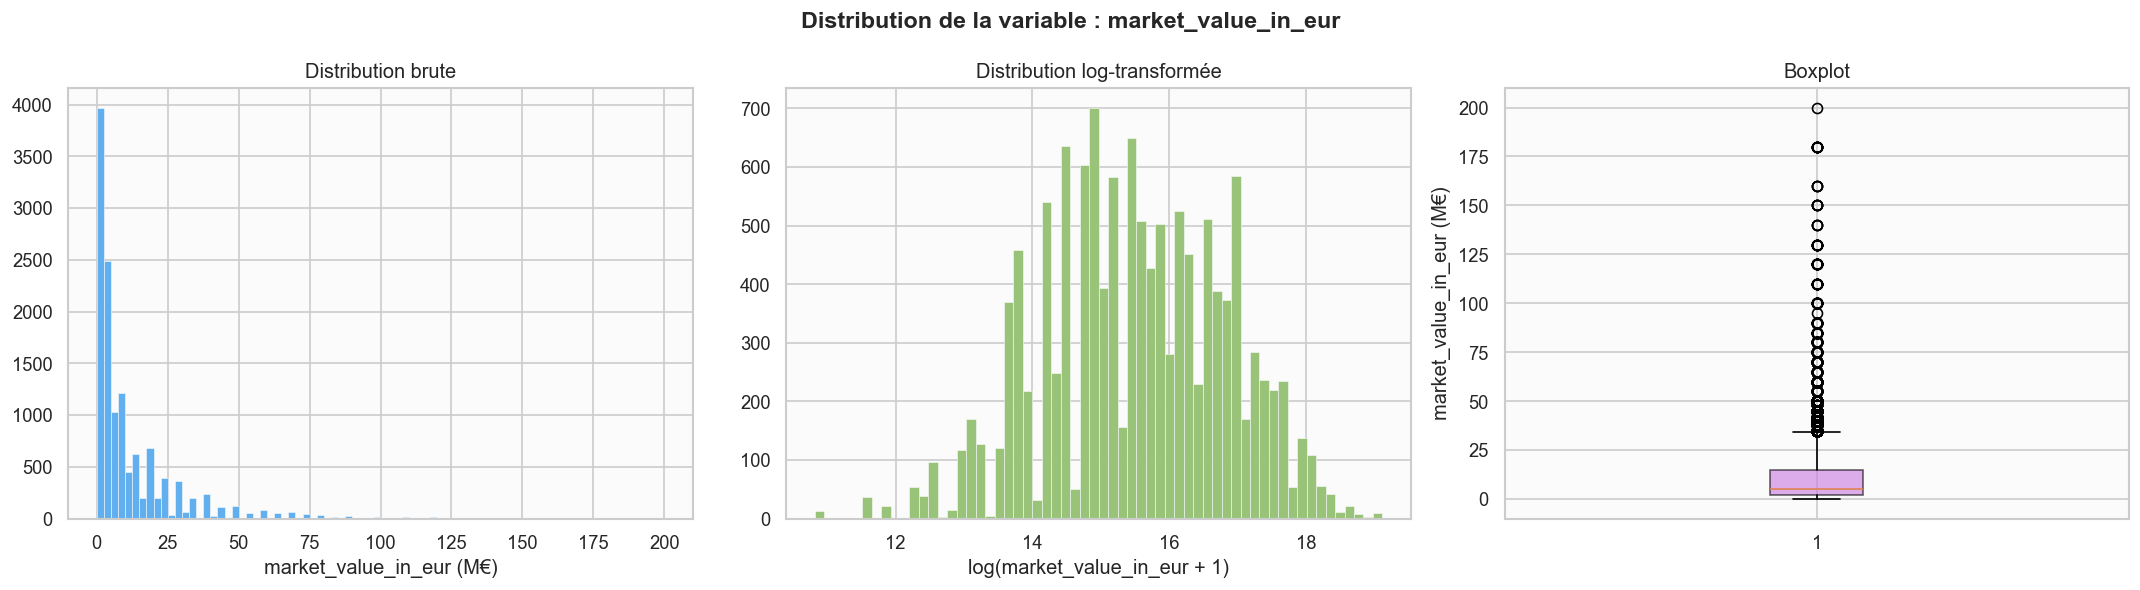

In [202]:
analyser_variable_cible(df_base, target_col=TARGET, dossier_sauvegarde=dossier_sauvegarde)

Distributions des variables numériques clés

Graphique sauvegardé sous : ..\outputs\eda\distributions_variables_numeriques_cles.png


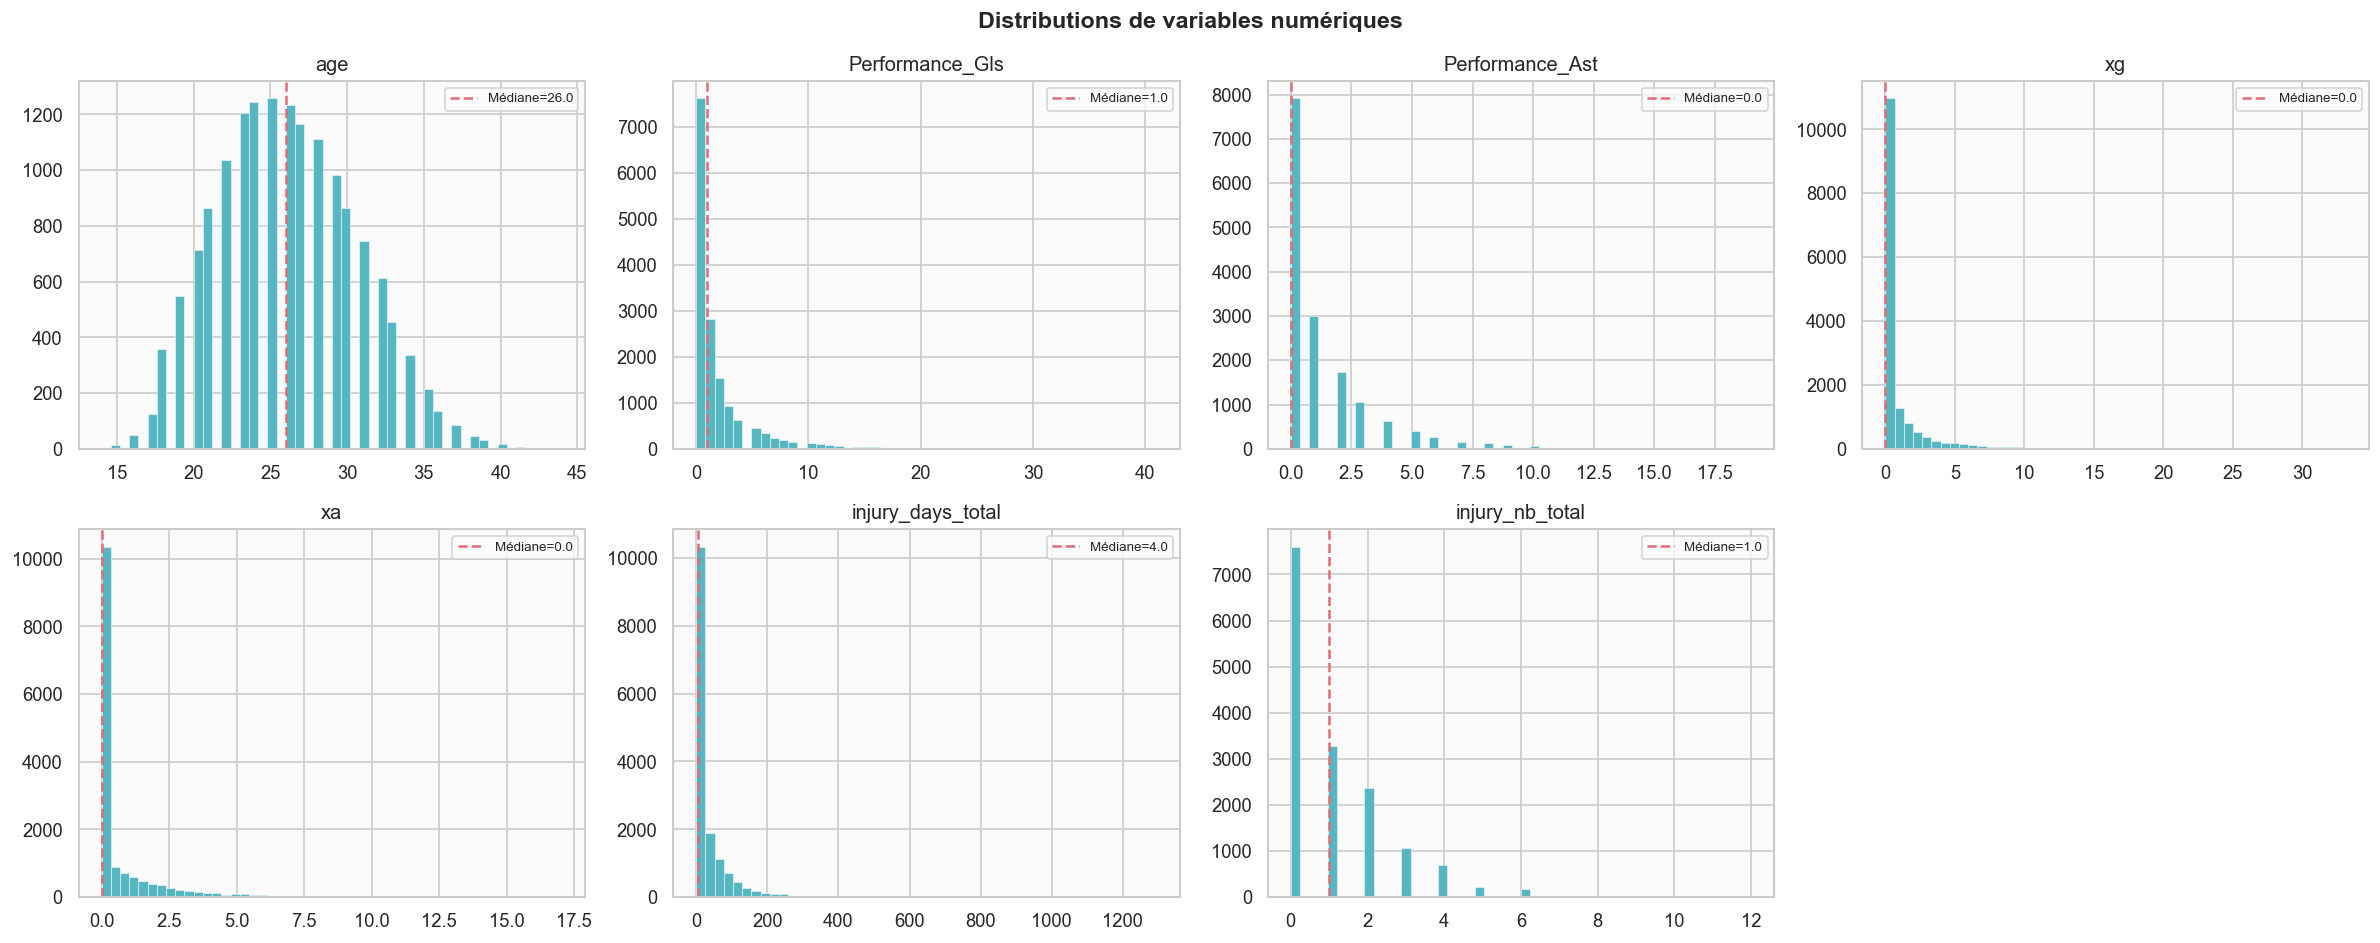

In [203]:
analyser_distributions_numeriques(df_base, cols_a_analyser=None, dossier_sauvegarde=dossier_sauvegarde)

Analyse des variables catégorielles

league (5 modalités encodées) :
ITA-Serie A           3292
ESP-La Liga           3280
FRA-Ligue 1           3072
ENG-Premier League    3064
GER-Bundesliga        2758

players_top_nations.png sauvegardé


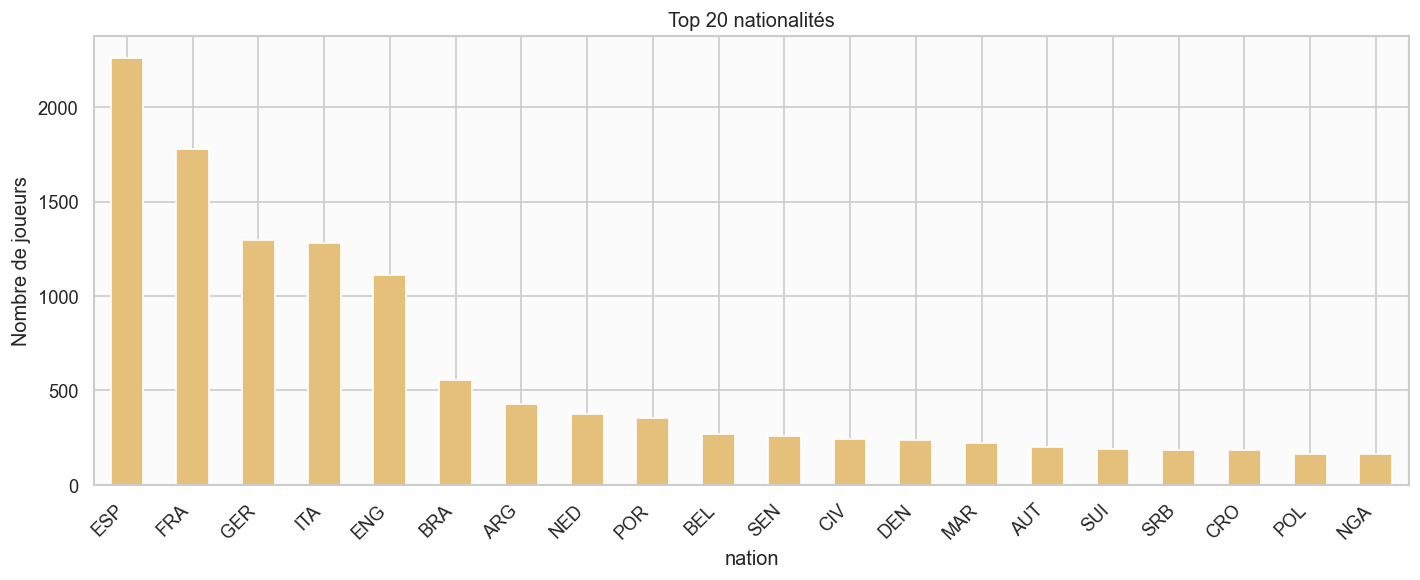

league.png sauvegardé


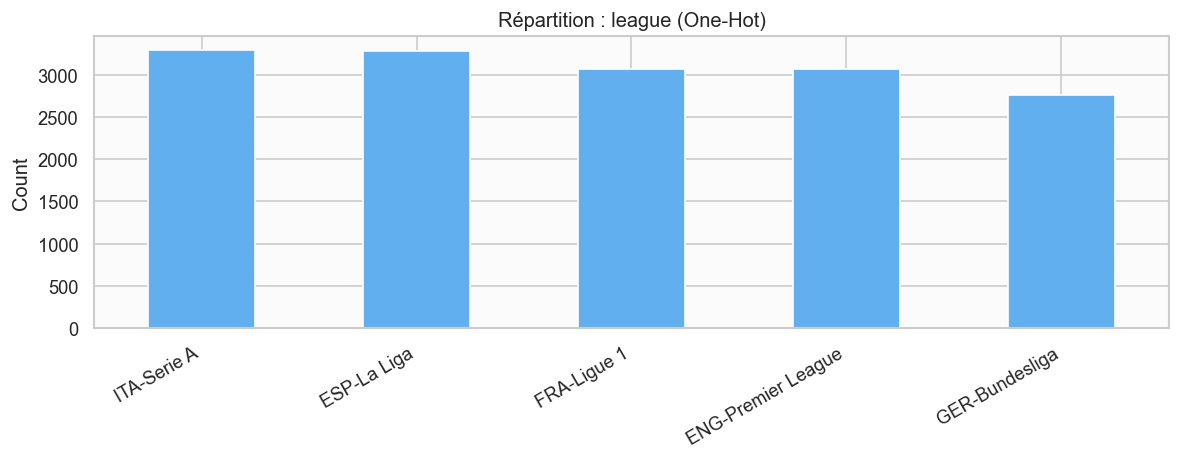

vm_par_league.png sauvegardé


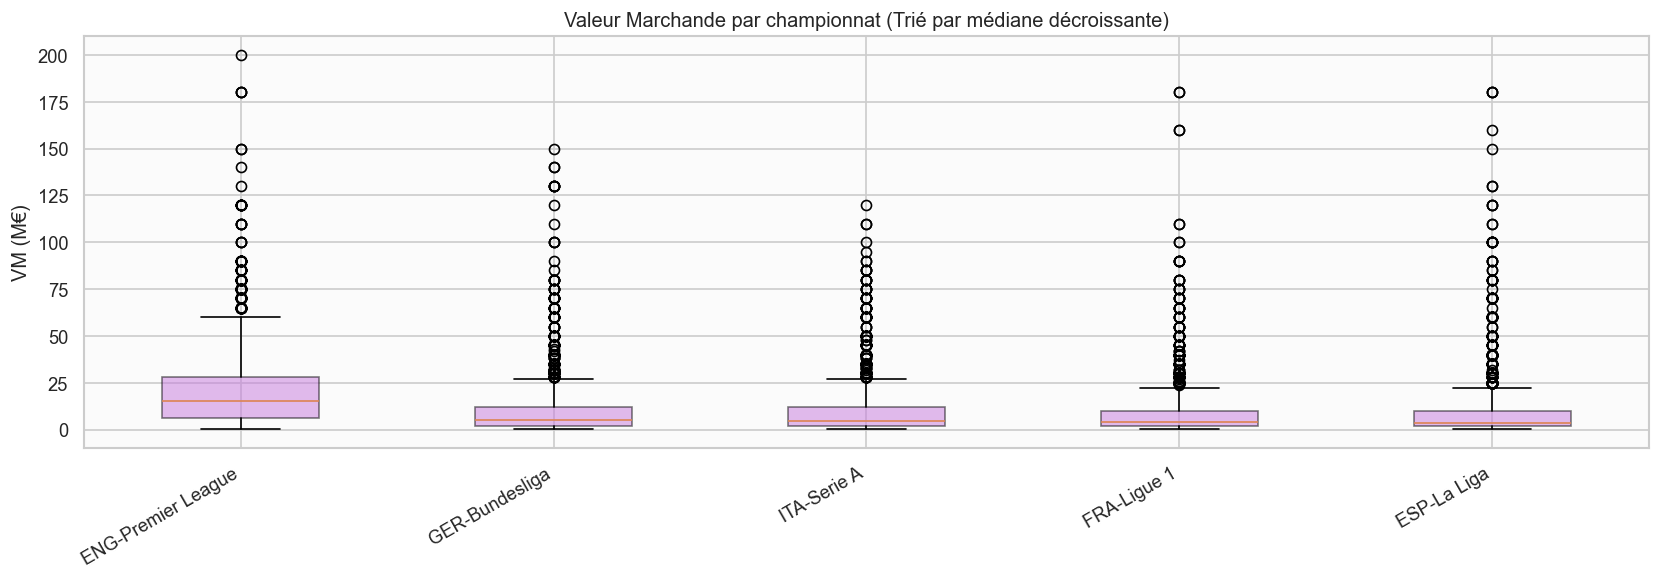

In [204]:
analyser_variables_categorielles(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

In [205]:
analyser_outliers(df_base)

Détection des outliers
         variable  outliers_IQR  pct_IQR  outliers_Zscore  total
              age            61      0.4               29  15466
  Performance_Gls          1517      9.8              359  15466
  Performance_Ast           740      4.8              331  15466
               xg          2108     13.6              385  15466
               xa          1959     12.7              414  15466
injury_days_total          1434      9.3              318  15466
  injury_nb_total           245      1.6              245  15466


Analyse des corrélations (cible : market_value_in_eur)

Corrélation linéaire avec la cible (variables clés)
                     market_value_in_eur
market_value_in_eur             1.000000
Performance_Gls                 0.466844
Performance_Ast                 0.446722
xg                              0.318616
xa                              0.310252
injury_nb_total                 0.130651
injury_days_total               0.042188
age                            -0.175933

matrice_correlation.png sauvegardé sous : ..\outputs\eda\matrice_correlation.png


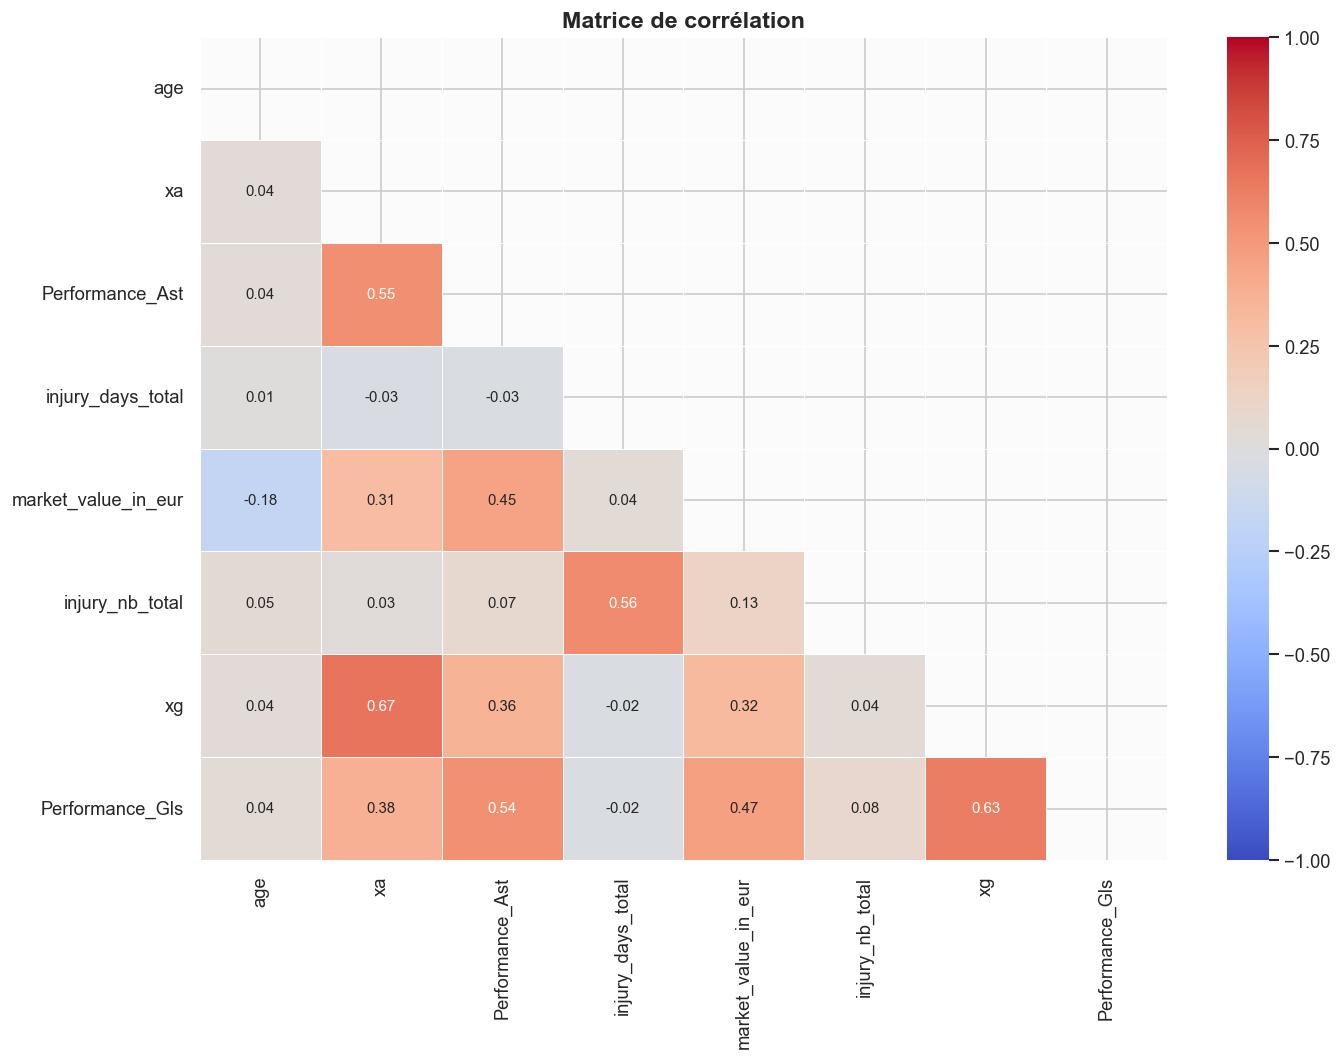


Top 20 des corrélations absolues avec market_value_in_eur (Toutes variables numériques)
market_value_in_eur_nor    1.000000
Team Success_onG           0.552116
Team Success_onG_nor       0.552116
Performance_G+A_nor        0.519425
Team Success_+/-_nor       0.519209
Standard_Sh                0.483420
Standard_Sh_nor            0.483420
Standard_SoT_nor           0.479340
Standard_SoT               0.479340
Performance_G-PK_nor       0.473369
Performance_G-PK           0.473369
Performance_Gls            0.466844
Performance_Gls_nor        0.466844
Standard_Gls_nor           0.466844
Performance_Ast_nor        0.446722
Performance_Ast            0.446722
xg_chain_nor               0.379609
Playing Time_Min_nor       0.356719
Playing Time_90s_nor       0.356705
90s_nor                    0.356705


In [206]:
analyser_correlations(df_base, TARGET, cols_cles=None, dossier_sauvegarde=dossier_sauvegarde)

## Segmentation par poste

Analyse du profil médian par poste

Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_profil_poste.png


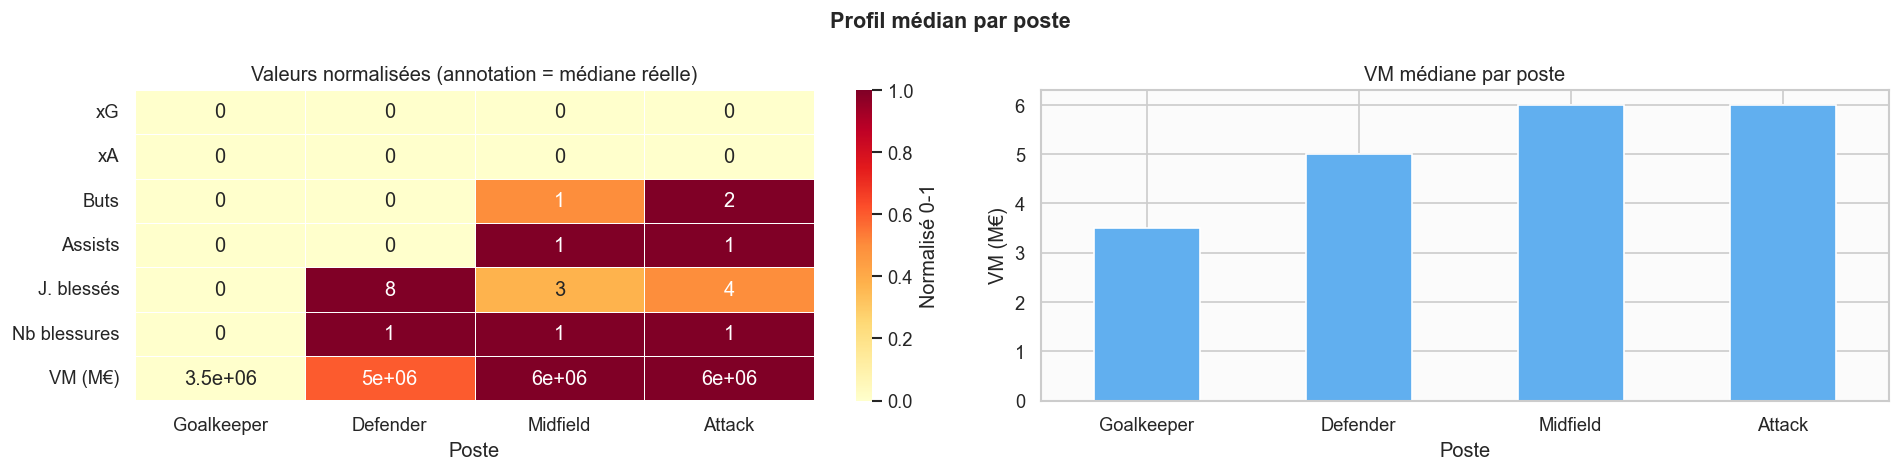

In [207]:
analyser_profil_par_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse de la distribution des âges par poste
Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_age_par_poste.png


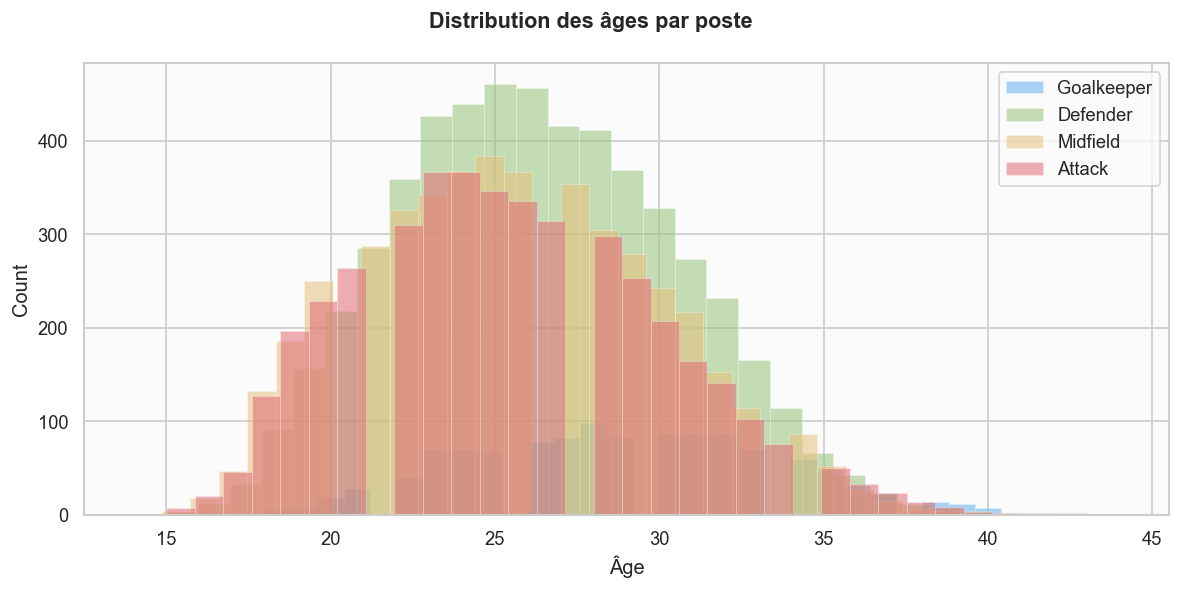


Âge médian par poste
position
Goalkeeper    29.0
Defender      26.0
Midfield      25.0
Attack        25.0


In [208]:
analyser_ages_par_poste(df_base, dossier_sauvegarde=dossier_sauvegarde, liste_couleurs=None)

Analyse croisée : VM médiane par championnat et par poste

Heatmap sauvegardée sous : ..\outputs\eda\feature_engineered_heatmap_league_pos.png


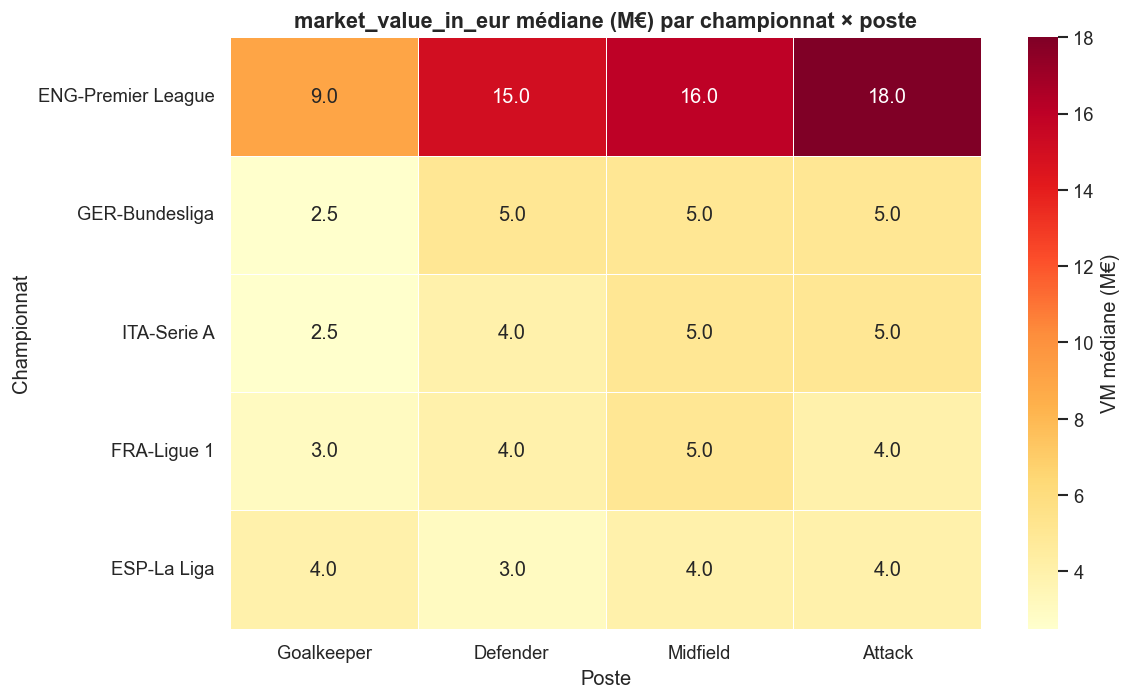

In [209]:
analyser_heatmap_league_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la distribution par championnat

Violin plot sauvegardé sous : ..\outputs\eda\feature_engineered_violin_league.png


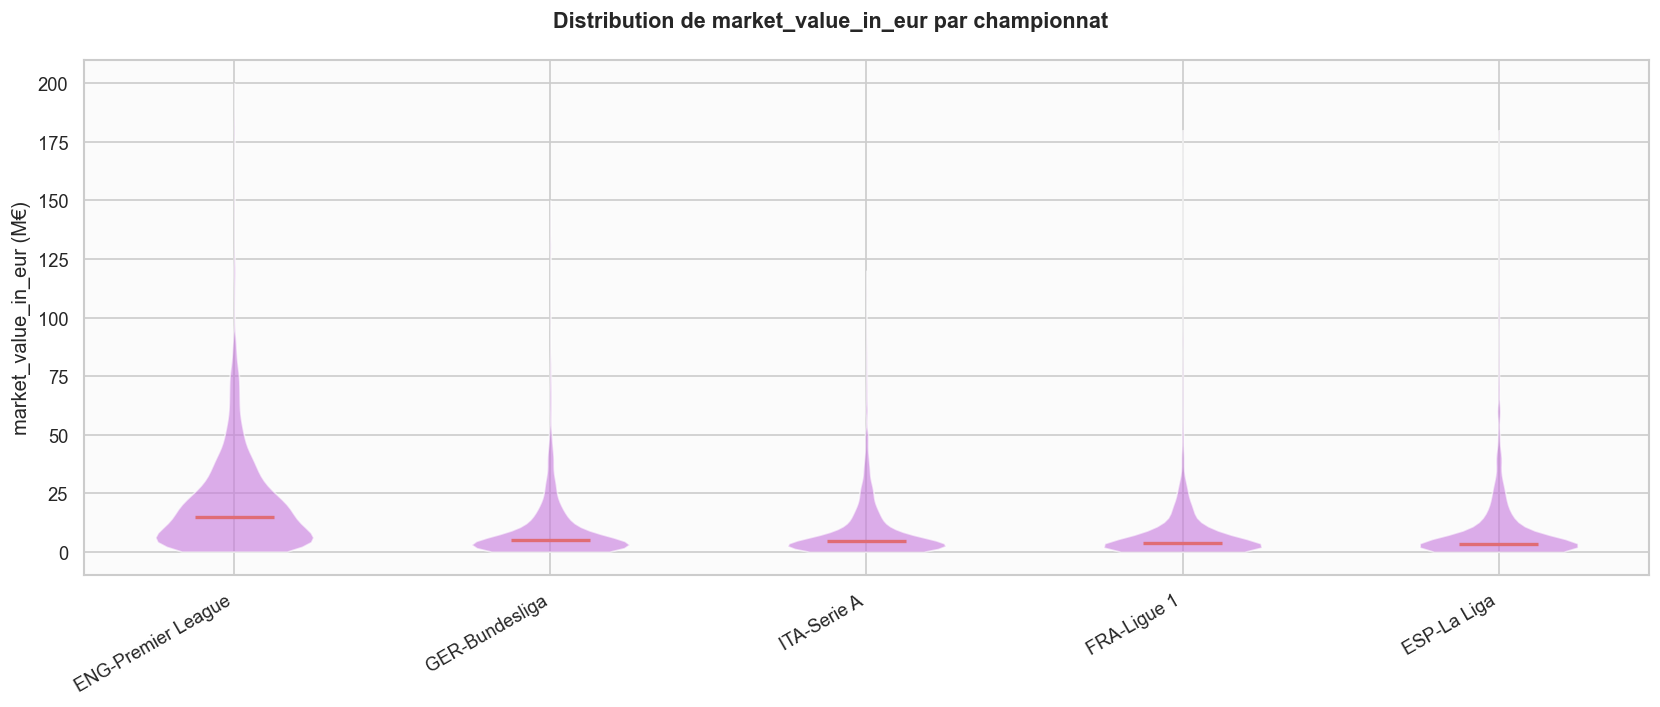

In [210]:
analyser_distribution_violin_league(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse des outliers et profils Spécifiques (cible : market_value_in_eur)

Joueurs avec market_value_in_eur ≥ 100M€ : 69 observations

Top 20 des joueurs les plus chers
           player position  age  market_value_in_eur        xg  Performance_Gls  injury_days_total
   Erling Haaland   Attack   25                200.0 28.795336               24                4.0
   Erling Haaland   Attack   23                180.0 31.653997               27               73.0
   Erling Haaland   Attack   22                180.0 32.761400               36               24.0
   Erling Haaland   Attack   24                180.0 23.954593               22               42.0
  Jude Bellingham Midfield   20                180.0 12.974516               19               40.0
  Vinicius Júnior   Attack   23                180.0  0.000000               15               77.0
    Kylian Mbappé   Attack   25                180.0  0.000000               27                0.0
    Kylian Mbappé   Attack   24        

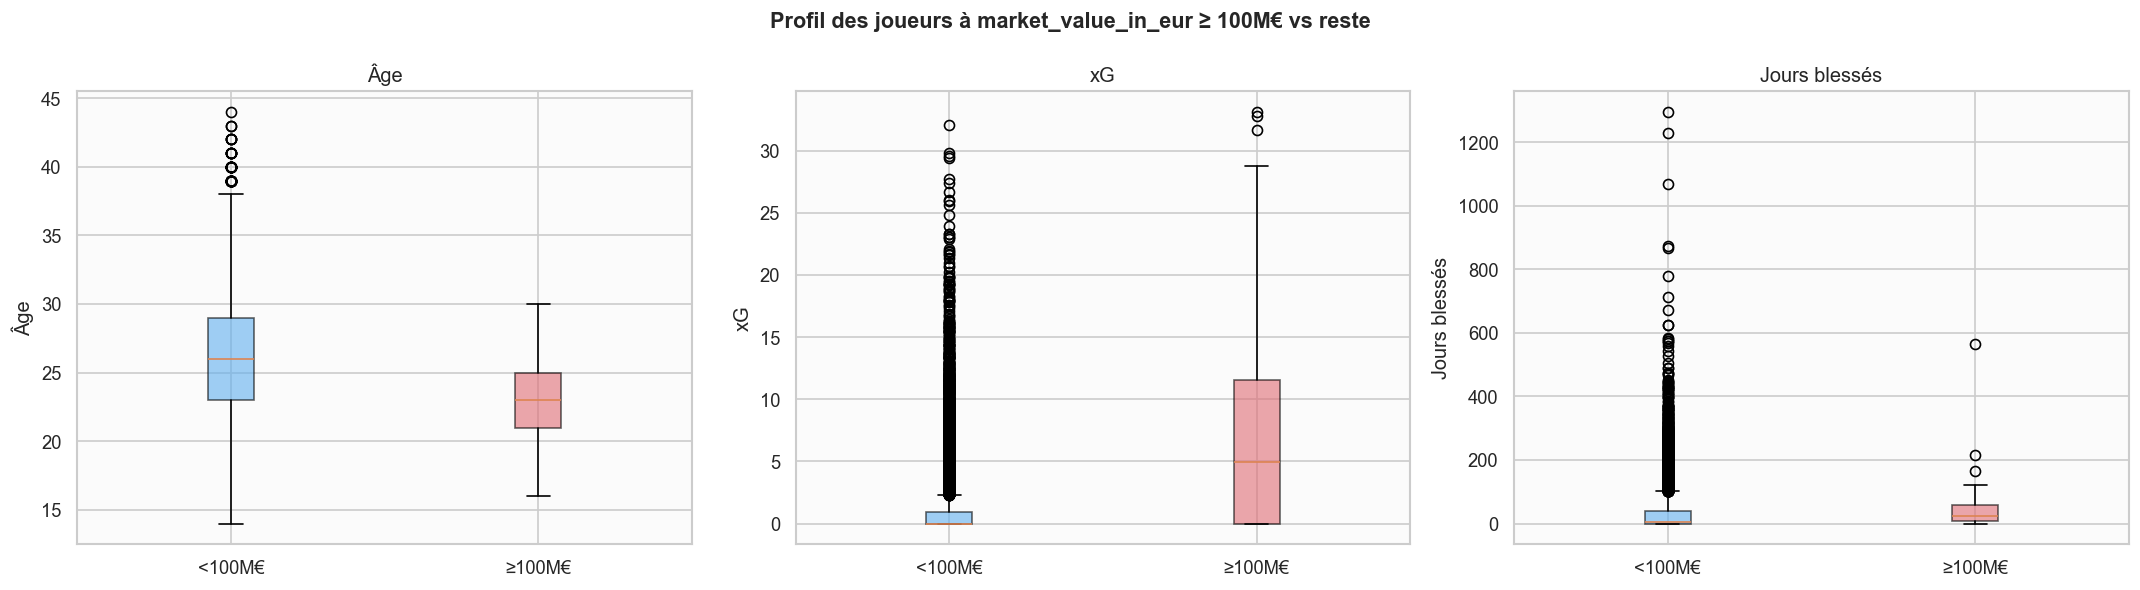

In [211]:
analyser_profil_outliers(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

In [212]:
verifier_coherence_jours_blessures(df_base)

Contrôle de cohérence : jours de blessures

Cohérence injury_days_total vs somme des composantes (15466/15466 lignes analysées) :
  Cohérents (diff = 0)           : 14,874
  Diff ≤ 1 jour                  : 14,874
  Diff > 1 jour (anomalie)       : 592
  Diff max                       : 1229 jours

Des incohérences ont été détectées. Cela peut provenir de blessures
 qui se chevauchent dans le temps ou de catégories non répertoriées ici.


Analyse de l'évolution temporelle par Saison (cible : market_value_in_eur)

Évolution VM par saison :
             Médiane (M€)  Moyenne (M€)  Nb joueurs
season_year                                        
2020                  5.0     10.589601        2505
2021                  5.0     10.671248        2419
2022                  5.0     11.328877        2476
2023                  5.0     12.144944        2413
2024                  6.5     13.440425        1731
2025                  9.0     16.601479        1285

Graphique sauvegardé sous : ..\outputs\eda\evolution_temporelle.png


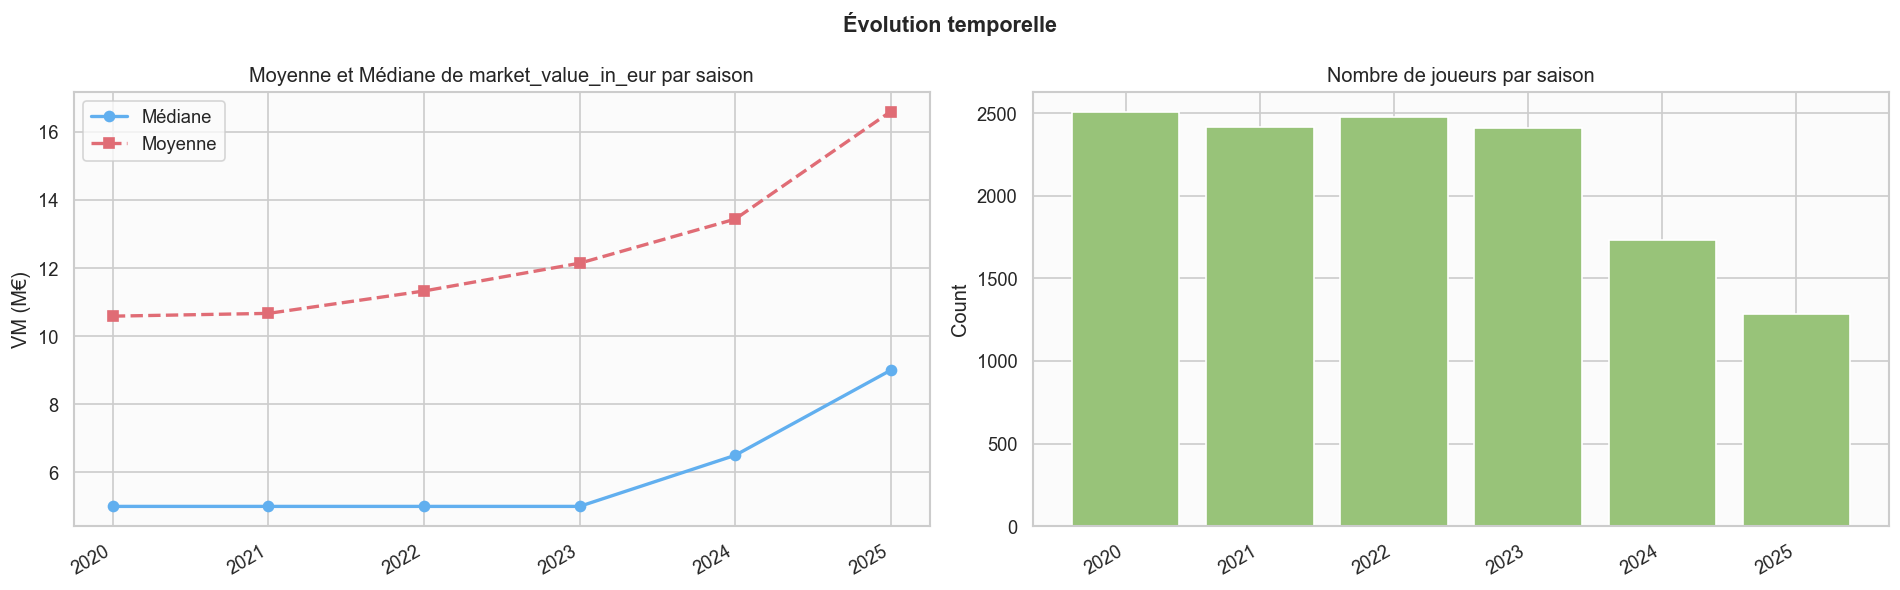

,Médiane (M€),Moyenne (M€),Nb joueurs
season_year,,,
2020,5.0,10.589601,2505
2021,5.0,10.671248,2419
2022,5.0,11.328877,2476
2023,5.0,12.144944,2413
2024,6.5,13.440425,1731
2025,9.0,16.601479,1285


In [213]:
analyser_evolution_temporelle_saison(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Démarrage de l'analyse du cycle de vie financier...
15464 observations valides trouvées pour l'analyse graphique.


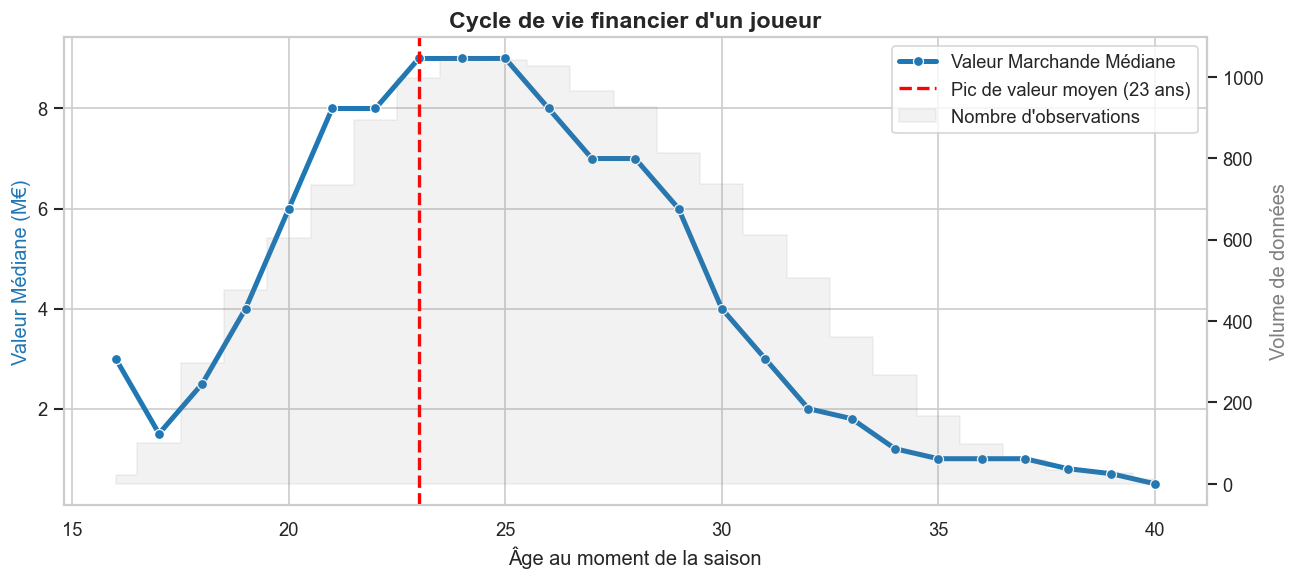


Graphique généré avec succès.


In [214]:
# Application de la fonction
df_base = analyser_cycle_vie_financier(df_base)

Démarrage de l'analyse de distribution des prix...
5 championnats détectés et ordonnés pour l'affichage.


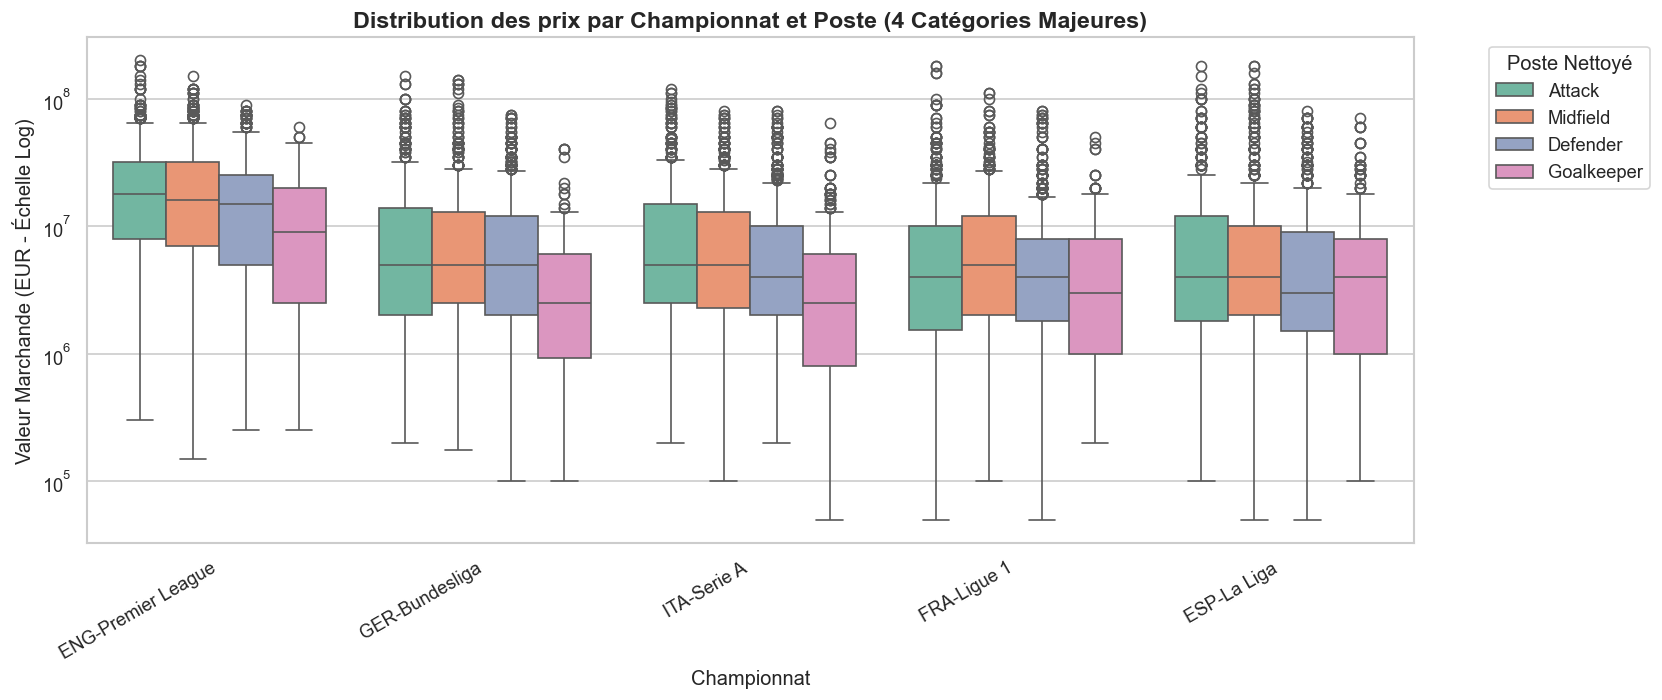


Boxplot généré avec succès.


In [215]:
analyser_distribution_prix_ligue_poste(df_base)

In [216]:
# On détecte les colinéarités
colinearites = detecter_top_colinearites(df_base, top_n=30)

# On affiche le tableau
display(colinearites)

Extraction du Top 30 des colinéarités (hors variables normalisées)...


,Variable_A,Variable_B,Correlation
0,Playing Time_90s,Playing Time_Starts,0.994
1,Performance_G-PK,Performance_Gls,0.978
2,Performance_Saves,Performance_GA,0.972
3,Performance_L,Performance_GA,0.971
4,pos_GK,Performance_Save%,0.969
5,Performance_PKatt,Performance_PK,0.968
6,Standard_SoT,Standard_Sh,0.957
7,injury_musculaire_nb_m,injury_musculaire_nb_d,0.952
8,injury_genou_nb_m,injury_genou_nb_d,0.949
9,injury_dos_bassin_nb_m,injury_dos_bassin_nb_d,0.947


Analyse des variables les plus explicatives pour : market_value_in_eur


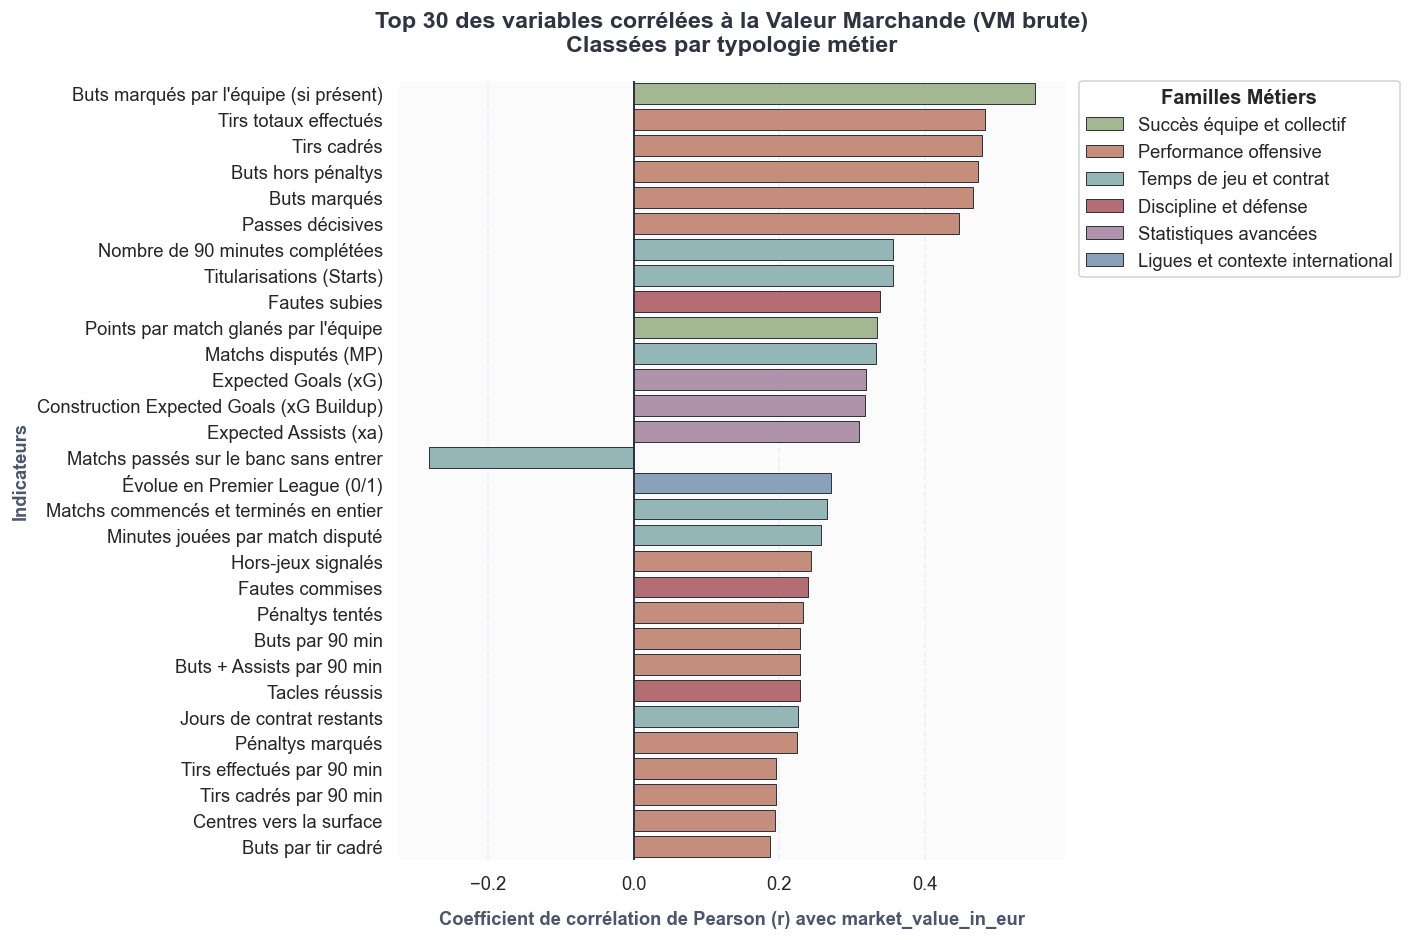

,Variable,Description,Famille,Corr_Cible_Brute
0,Team Success_onG,Buts marqués par l'équipe (si présent),Succès équipe et collectif,0.552
1,Standard_Sh,Tirs totaux effectués,Performance offensive,0.483
2,Standard_SoT,Tirs cadrés,Performance offensive,0.479
3,Performance_G-PK,Buts hors pénaltys,Performance offensive,0.473
4,Performance_Gls,Buts marqués,Performance offensive,0.467
5,Performance_Ast,Passes décisives,Performance offensive,0.447
6,Playing Time_90s,Nombre de 90 minutes complétées,Temps de jeu et contrat,0.357
7,Playing Time_Starts,Titularisations (Starts),Temps de jeu et contrat,0.356
8,Performance_Fld,Fautes subies,Discipline et défense,0.338
9,Team Success_PPM,Points par match glanés par l'équipe,Succès équipe et collectif,0.334


In [217]:
# On applique la fonction
tableau_importance = analyser_variables_les_plus_explicatives(df_base, target_col=TARGET, top_n=30)

# On affiche le tableau propre sous le graphique
display(tableau_importance)

In [218]:
df_base

,player,team,nation,age,Playing Time_MP,Playing Time_Starts,Playing Time_90s,Performance_Gls,Performance_Ast,Performance_G-PK,...,injury_minor_unknown_nb_m_nor,injury_musculaire_nor,injury_genou_nor,injury_cheville_pied_nor,injury_mollet_tibia_nor,injury_dos_bassin_nor,injury_trauma_severe_nor,injury_medical_repos_nor,injury_minor_unknown_nor,contrat_jours_restants_nor
0,Aaron Ciammaglichella,Torino,ITA,24,1,0,0.0,0,0,0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.285742
1,Aaron Connolly,Brighton,IRL,20,17,9,8.8,2,1,2,...,0.107143,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.214356
2,Aaron Connolly,Brighton,IRL,21,4,1,1.7,0,0,0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.285742
3,Aaron Cresswell,West Ham United,ENG,31,36,36,35.2,0,8,0,...,0.000000,0.333333,0.0,0.5,0.0,0.0,0.0,0.0,0.000000,0.357129
4,Aaron Cresswell,West Ham United,ENG,32,31,31,30.3,2,3,2,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.285742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15461,Šime Vrsaljko,Atlético Madrid,CRO,28,9,6,5.8,0,0,0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.285742
15462,Šime Vrsaljko,Atlético Madrid,CRO,29,21,10,10.2,1,2,1,...,0.178571,0.000000,0.0,0.0,0.0,0.0,0.5,0.0,0.333333,0.285742
15463,Ștefan Radu,Lazio,ROU,34,31,30,27.3,0,3,0,...,0.089286,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.285742
15464,Ștefan Radu,Lazio,ROU,35,10,6,6.2,0,0,0,...,0.053571,0.000000,0.0,0.0,0.0,0.0,0.0,0.5,0.333333,0.285742
